## **Exploratory Data Analysis & Intro**

**Questions to Answer**

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

**Exploratory Data Analysis for all Data roles**

Roles to explore

In [ ]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# this date column was type 'str', now changed to type 'datetime'

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
# converting string formatted list to actual list

d:\Program Files\Anaconda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter for US Data Analyst roles

In [5]:
df_us_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

In [7]:
df_us_da

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,NaN,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"
73,Data Analyst,Entry level / Systems Data Analyst (Remote),Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-16 13:18:22,True,True,United States,NaN,NaN,NaN,Soft Magic,"[word, excel, powerpoint, outlook]","{'analyst_tools': ['word', 'excel', 'powerpoin..."
79,Data Analyst,Data Analyst/Report Writer,"Austin, TX",via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-08-07 13:18:27,True,False,United States,NaN,NaN,NaN,Nesco Resource,"[sas, sas, word, excel]","{'analyst_tools': ['sas', 'word', 'excel'], 'p..."
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH,Anywhere,via LinkedIn,Full-time,True,"New York, United States",2023-06-10 13:00:05,False,False,United States,NaN,NaN,NaN,Get It Recruit - Information Technology,"[oracle, azure, power bi, excel, word, powerpo...","{'analyst_tools': ['power bi', 'excel', 'word'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785603,Data Analyst,Junior Data Analyst,"Santa Monica, CA",via Trabajo.org,Full-time,False,"California, United States",2023-09-12 06:00:50,False,False,United States,NaN,NaN,NaN,"Ramax Search, Inc.","[sql, vba, python, excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']..."
785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,NaN,NaN,NaN,Planet Group,[microsoft teams],{'sync': ['microsoft teams']}
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN


In [ ]:
df_plot = df_us_da['job_location'].value_counts().head(10).to_frame()
# shows top 10 locations in the US with their counts, and turning it into dataframe

In [ ]:
df_plot
# .value_counts() function auto names a new column 'count'

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


Text(0, 0.5, '')

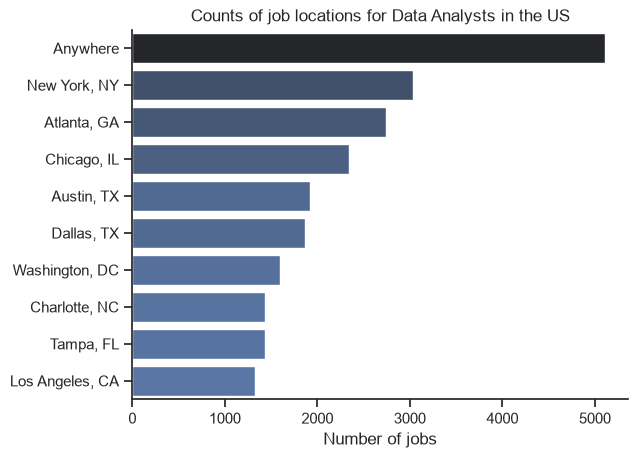

In [ ]:
sns.barplot(data = df_plot, x = 'count', y = 'job_location', hue = 'count', palette = 'dark:b_r', legend = False)
# hue - color fading; palette - color

sns.set_theme(style = 'ticks')
sns.despine()  # removes borders

plt.title('Counts of job locations for Data Analysts in the US')
plt.xlabel('Number of jobs')
plt.ylabel('')

Job opportunities

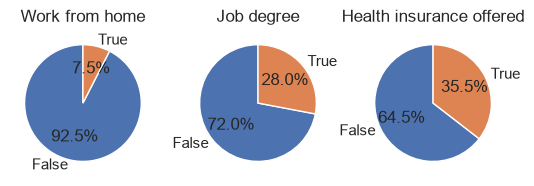

In [ ]:
fig, ax = plt.subplots(1, 3)
# fig, ax are just randomly assigned variables to make subplots
    
dict_column = {
    'job_work_from_home': 'Work from home',
    'job_no_degree_mention': 'Job degree',
    'job_health_insurance': 'Health insurance offered'
}
# column: title

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_us_da[column].value_counts(), startangle = 90, autopct = ('%1.1f%%'), labels = ['False', 'True'])
    ax[i].set_title(title)

Job companies

Text(0, 0.5, '')

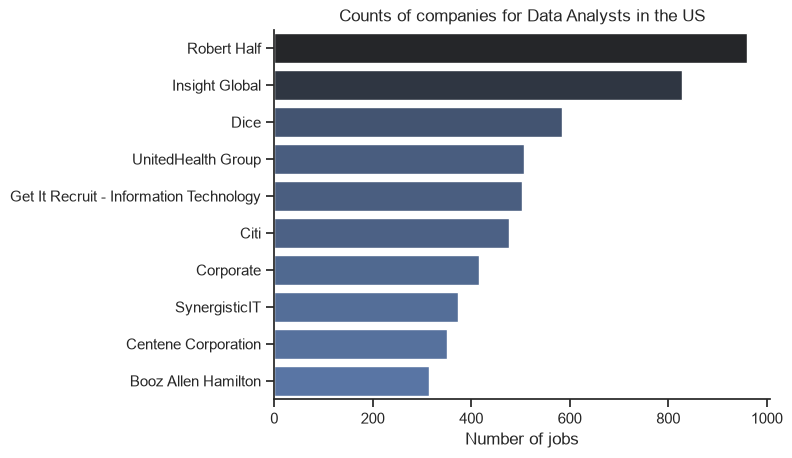

In [ ]:
df_plot = df_us_da['company_name'].value_counts().head(10).to_frame()

sns.barplot(data = df_plot, x = 'count', y = 'company_name', hue = 'count', palette = 'dark:b_r', legend = False)
sns.set_theme(style = 'ticks')
sns.despine()

plt.title('Counts of companies for Data Analysts in the US')
plt.xlabel('Number of jobs')
plt.ylabel('')

Salaries for Data jobs in top countries

Text(0.5, 1.0, 'Salaries in top countries')

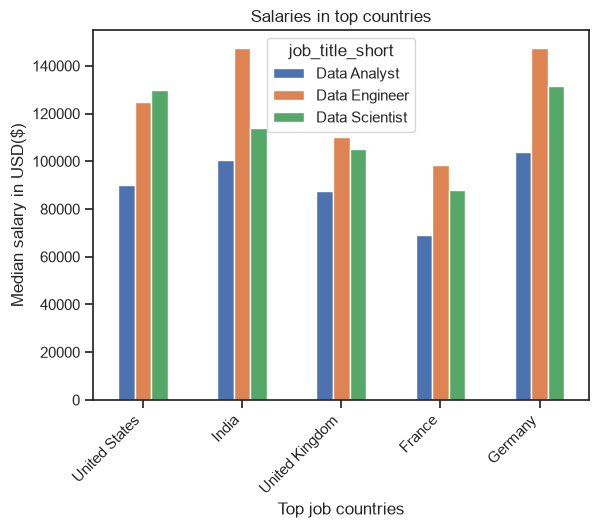

In [ ]:
top_countries = df['job_country'].value_counts().head().index
# shows just the names of top 5 countries with the most counts

df_jobcountry_salary = df.pivot_table(index = 'job_country', columns = "job_title_short", values = 'salary_year_avg', aggfunc = 'median')
# pivot table .loc showing just top 5 countries
df_jobcountry_salary = df_jobcountry_salary.loc[top_countries]

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_jobcountry_salary = df_jobcountry_salary[job_titles]
# shows info on job_title including only 3 for those top 5 countries 

df_jobcountry_salary.plot(kind='bar')
plt.xlabel('Top job countries')
plt.ylabel('Median salary in USD($)')
plt.xticks(rotation=45, ha='right')
plt.title('Salaries in top countries')



Top Data jobs in the US

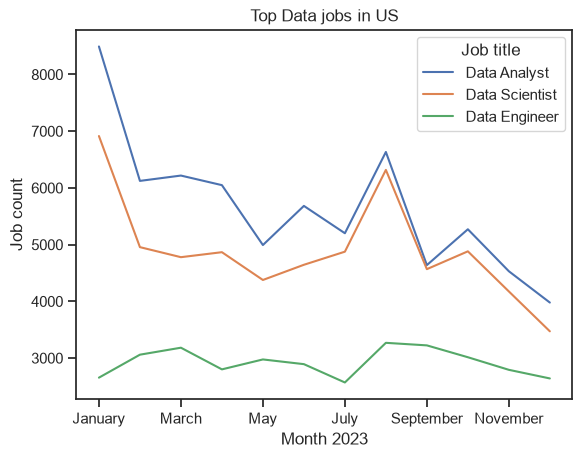

In [ ]:
df_us = df[df['job_country'] == 'United States']

df_us['job_posted_month'] = df_us['job_posted_date'].dt.strftime('%B')
# new column - job_posted_month - showing only month name: January...

df_us_pivot = df_us.pivot_table(index = 'job_posted_month', columns = 'job_title_short', aggfunc = 'size')
df_us_pivot.reset_index(inplace = True)

df_us_pivot['month'] = pd.to_datetime(df_us_pivot['job_posted_month'], format = '%B').dt.month
# new column - month - showing only month number

df_us_pivot.sort_values('month', inplace = True) 
df_us_pivot.set_index('job_posted_month', inplace = True)
df_us_pivot.drop(columns = 'month', inplace = True)

top3 = df_us['job_title_short'].value_counts().head(3)
top3 = top3.index.tolist()

df_us_pivot[top3].plot(kind = 'line')
plt.title('Top Data jobs in US')
plt.xlabel('Month 2023')
plt.ylabel('Job count')
plt.legend(title = 'Job title')

Top skills for Data Analysts

Text(0.5, 0, '')

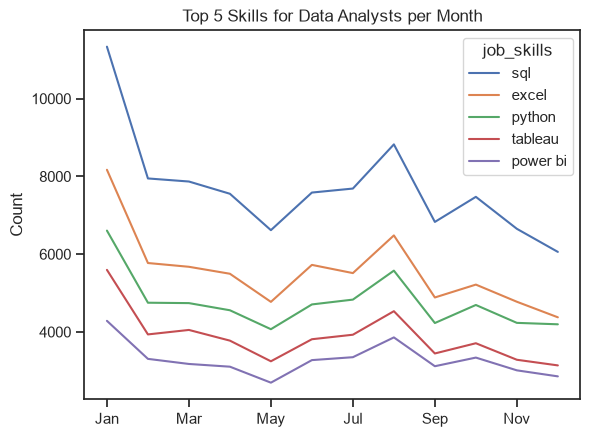

In [ ]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

df_da['job_month'] = df_da['job_posted_date'].dt.month

df_da_exploded = df_da.explode('job_skills')

df_da_pivot = df_da_exploded.pivot_table(index = 'job_month', columns='job_skills',  aggfunc = 'size', fill_value = 0)

df_da_pivot.loc['Total'] = df_da_pivot.sum()
# creates a new row showing sum values
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending =  False).index]
df_da_pivot = df_da_pivot.drop('Total')
# sorted by sum and then drop that new column

df_da_pivot = df_da_pivot.reset_index()

df_da_pivot['job_posted_month'] = df_da_pivot['job_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_pivot = df_da_pivot.set_index('job_posted_month')
df_da_pivot = df_da_pivot.drop(columns = 'job_month')

df_da_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')